In [1]:
import mpemba

import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt

<Axes: xlabel='T'>

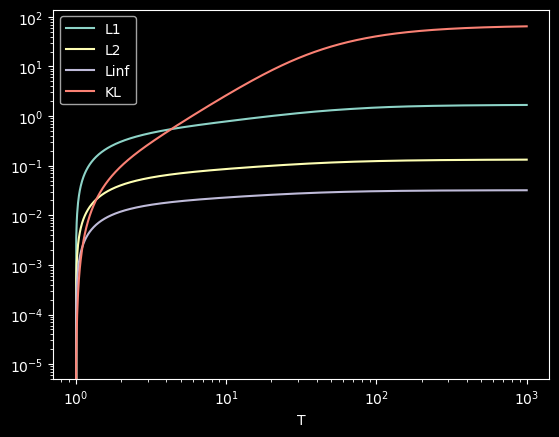

In [2]:
potential = mpemba.special_potentials.AsymmetricDoubleWellPotential(E_tilt=0.4, x_min=-5, x_max=5, force_asymmetry=0.5)

k_BTs = np.logspace(np.log(1)/np.log(10), np.log(1000)/np.log(10), 1000)
D_L1s = np.zeros_like(k_BTs)
D_L2s = np.zeros_like(k_BTs)
D_Linfs = np.zeros_like(k_BTs)
D_KLs = np.zeros_like(k_BTs)
x= potential.mesh(500)
boltz_c = potential.boltzmann(x, 1)
for i, k_BT in enumerate(k_BTs):
    boltz = potential.boltzmann(x, k_BT)
    D_L1s[i] = mpemba.distance_functions.L1(boltz, boltz_c, np.diff(x)[0], axis=0)
    D_L2s[i] = mpemba.distance_functions.Lp_constructor(2)(boltz, boltz_c, np.diff(x)[0], axis=0)
    D_Linfs[i] = mpemba.distance_functions.Lp_constructor(np.inf)(boltz, boltz_c, np.diff(x)[0], axis=0)
    D_KLs[i] = mpemba.distance_functions.KL_constructor(0)(boltz, boltz_c, np.diff(x)[0], axis=0)
df = pd.DataFrame(np.array([k_BTs, D_L1s, D_L2s, D_Linfs, D_KLs]).T, columns=['T', 'L1', 'L2', 'Linf', 'KL'])
df.plot(logx=True, logy=True, x='T')

In [5]:
df.to_csv("L1.csv", index=False)